In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# CNN — Extracción de Embeddings desde Imágenes TINTOlib

## 1. Librerías y configuración

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ── AJUSTA ESTAS RUTAS ────────────────────────────────────────────
INDEX_PATH  = '/content/drive/MyDrive/imagenes_index.csv'   # generado en notebook 04
OUTPUT_EMB  = '/content/drive/MyDrive/embeddings.csv'       # embeddings para modelos ML
IMG_DIR     = '/content/drive/MyDrive/imagenes_tinto'       # carpeta con imágenes
# ─────────────────────────────────────────────────────────────────

IMG_SIZE    = 64      # tamaño imagen TINTOlib (20x20)
BATCH_SIZE  = 16
EPOCHS      = 80
LR          = 3e-4
N_CLASSES   = 3       # S1, S2, S3
EMBED_DIM   = 32      # dimensión de los embeddings
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Usar GPU si está disponible (Colab)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
print(f'PyTorch versión: {torch.__version__}')

Dispositivo: cpu
PyTorch versión: 2.11.0+cpu


## 2. Carga de imágenes

Cargamos el índice generado por TINTOlib y preparamos los datos para PyTorch.
Nota: las carpetas se guardaron como `00`, `01`, `02` — el índice ya las contempla.

In [62]:
# Cargar índice de imágenes
df_idx = pd.read_csv(INDEX_PATH)
print(f'Total imágenes: {len(df_idx)}')
print(f'Columnas: {list(df_idx.columns)}')
print(f'\nDistribución:')
print(df_idx['stress_label'].value_counts().sort_index())
df_idx.head(3)

Total imágenes: 770
Columnas: ['imagen_path', 'clase_num', 'stress_label']

Distribución:
stress_label
0    443
1    220
2    107
Name: count, dtype: int64


,imagen_path,clase_num,stress_label
0,imagenes_tinto/00/000000.png,0,0
1,imagenes_tinto/00/000001.png,0,0
2,imagenes_tinto/00/000002.png,0,0


In [32]:
print(df_idx['imagen_path'].iloc[0])

imagenes_tinto/00/000000.png


In [ ]:
ruta = df_idx['imagen_path'].iloc[0]

print(ruta)
print(os.path.exists(ruta))

imagenes_tinto/00/000000.png
False


In [ ]:
ruta_completa = "/content/drive/MyDrive/" + ruta

print(os.path.exists(ruta_completa))

True


In [ ]:
df_idx['imagen_path'] = '/content/drive/MyDrive/' + df_idx['imagen_path']

In [ ]:
print(df_idx['imagen_path'].iloc[0])

/content/drive/MyDrive/imagenes_tinto/00/000000.png


In [63]:
# Verificar que las imágenes existen
df_idx['imagen_path'] = '/content/drive/MyDrive/' + df_idx['imagen_path']
df_idx['existe'] = df_idx['imagen_path'].apply(os.path.exists)
n_ok      = df_idx['existe'].sum()
n_faltantes = (~df_idx['existe']).sum()
print(f'Imágenes encontradas: {n_ok}')
print(f'Imágenes faltantes:   {n_faltantes}')

if n_faltantes > 0:
    print('\n⚠ Ejemplos de rutas no encontradas:')
    print(df_idx[~df_idx['existe']]['imagen_path'].head(3).tolist())
    print('\nEjemplos de rutas encontradas:')
    print(df_idx[df_idx['existe']]['imagen_path'].head(3).tolist())

# Usar solo imágenes que existen
df_idx = df_idx[df_idx['existe']].reset_index(drop=True)
print(f'\nImágenes válidas para usar: {len(df_idx)}')

Imágenes encontradas: 770
Imágenes faltantes:   0

Imágenes válidas para usar: 770


In [64]:
# Codificar etiquetas numéricamente
# S1=0, S2=1, S3=2
le = LabelEncoder()
df_idx['label_enc'] = le.fit_transform(df_idx['stress_label'])
print(f'Clases: {list(le.classes_)}')
print(f'Codificación: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Clases: [np.int64(0), np.int64(1), np.int64(2)]
Codificación: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}


In [65]:
# Dataset PyTorch
class StressImageDataset(Dataset):
    """
    Dataset de imágenes TINTOlib para PyTorch.
    Carga cada imagen, la convierte a tensor y devuelve (imagen, etiqueta).
    """
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        ruta  = self.df.loc[idx, 'imagen_path']
        label = self.df.loc[idx, 'label_enc']

        # Cargar imagen en RGB
        img = cv2.imread(ruta)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        if self.transform:
            img = self.transform(img)
        else:
            img = torch.tensor(img, dtype=torch.float32).permute(2,0,1) / 255.0

        return img, torch.tensor(label, dtype=torch.long)


# Transformaciones
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),          # [0,255] → [0,1]
    transforms.Normalize(           # normalizar por canal
        mean=[0.5, 0.5, 0.5],
        std =[0.5, 0.5, 0.5]
    )
])

# Split train/test (80/20 estratificado)
df_train, df_test = train_test_split(
    df_idx, test_size=0.2,
    stratify=df_idx['label_enc'],
    random_state=RANDOM_SEED
)

train_ds = StressImageDataset(df_train, transform=transform)
test_ds  = StressImageDataset(df_test,  transform=transform)
full_ds  = StressImageDataset(df_idx,   transform=transform)  # para embeddings

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)
full_loader  = DataLoader(full_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train: {len(train_ds)} imágenes')
print(f'Test:  {len(test_ds)}  imágenes')

Train: 616 imágenes
Test:  154  imágenes


## 3. Arquitectura CNN

CNN simple de 3 capas convolucionales seguida de una capa densa de `EMBED_DIM=64` neuronas.
Esta capa densa es la que usaremos como **embedding** — representa cada imagen en un espacio de 64 dimensiones.
La última capa clasifica en S1/S2/S3.

In [71]:
class StressCNN(nn.Module):
    """
    CNN para imágenes TINTOlib 64x64.
    Arquitectura conservadora con regularización fuerte
    para dataset pequeño (770 muestras).
    """
    def __init__(self, n_classes=N_CLASSES, embed_dim=EMBED_DIM):
        super(StressCNN, self).__init__()

        self.features = nn.Sequential(
            # Bloque 1 — 64x64 → 32x32
            nn.Conv2d(3, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloque 2 — 32x32 → 16x16
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloque 3 — 16x16 → 8x8
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(4),  # → 4x4
        )

        self.embedding = nn.Sequential(
            nn.Flatten(),             # 32 * 4 * 4 = 512
            nn.Linear(512, embed_dim),
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.4),          # dropout solo antes de clasificar
            nn.Linear(embed_dim, n_classes)
        )

    def forward(self, x):
        x   = self.features(x)
        emb = self.embedding(x)
        out = self.classifier(emb)
        return out

    def get_embedding(self, x):
        x = self.features(x)
        return self.embedding(x)




# Después de definir el modelo, inicializar pesos
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.constant_(m.bias, 0.01)
    elif isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out')

model = StressCNN().to(device)
model.apply(init_weights)
print('✓ Pesos inicializados')
print(model)
print(f'\nParámetros totales: {sum(p.numel() for p in model.parameters()):,}')

✓ Pesos inicializados
StressCNN(
  (features): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=4)
  )
  (embedding): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=512, out_features=32, bias=True)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.4, inplace=False)
    (1): Linear(in_features=32, out_features=3, bias=True)
  )
)

Parámetros totales: 22,547


## 4. Entrenamiento

Entrenamos la CNN con CrossEntropyLoss (que maneja desbalance con `weight`) y Adam optimizer.
Usamos `class_weight` para compensar el desbalance S1 > S2 > S3.

In [72]:
# Calcular pesos por clase para manejar desbalance
conteos = df_train['label_enc'].value_counts().sort_index()
total   = len(df_train)
pesos   = torch.tensor(
    [total / (N_CLASSES * conteos[i]) for i in range(N_CLASSES)],
    dtype=torch.float32
).to(device)

print(f'Pesos por clase: {pesos.cpu().numpy().round(3)}')
print(f'  S1 (sin estrés): {pesos[0].item():.3f}')
print(f'  S2 (leve):       {pesos[1].item():.3f}')
print(f'  S3 (alto):       {pesos[2].item():.3f}')

criterion = nn.CrossEntropyLoss(weight=pesos)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

Pesos por clase: [0.58  1.167 2.388]
  S1 (sin estrés): 0.580
  S2 (leve):       1.167
  S3 (alto):       2.388


In [73]:
# Loop de entrenamiento
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    # ── TRAIN ──────────────────────────────────────────────────
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item() * imgs.size(0)
        preds          = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += imgs.size(0)

    # ── VALIDACIÓN ─────────────────────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs  = model(imgs)
            loss     = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            preds     = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += imgs.size(0)

    scheduler.step()

    # Métricas del epoch
    t_loss = train_loss / train_total
    t_acc  = train_correct / train_total
    v_loss = val_loss / val_total
    v_acc  = val_correct / val_total

    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:>3}/{EPOCHS} | '
              f'Train loss: {t_loss:.4f} acc: {t_acc:.3f} | '
              f'Val loss: {v_loss:.4f} acc: {v_acc:.3f}')

print('\n✓ Entrenamiento completado')

Epoch   1/80 | Train loss: 1.1551 acc: 0.391 | Val loss: 1.0974 acc: 0.578
Epoch   5/80 | Train loss: 1.1029 acc: 0.401 | Val loss: 1.0980 acc: 0.578
Epoch  10/80 | Train loss: 1.0962 acc: 0.508 | Val loss: 1.0973 acc: 0.578
Epoch  15/80 | Train loss: 1.0980 acc: 0.565 | Val loss: 1.0974 acc: 0.578
Epoch  20/80 | Train loss: 1.0983 acc: 0.519 | Val loss: 1.0974 acc: 0.578
Epoch  25/80 | Train loss: 1.0970 acc: 0.519 | Val loss: 1.0974 acc: 0.578
Epoch  30/80 | Train loss: 1.0960 acc: 0.487 | Val loss: 1.0975 acc: 0.578
Epoch  35/80 | Train loss: 1.0978 acc: 0.456 | Val loss: 1.0975 acc: 0.578
Epoch  40/80 | Train loss: 1.0970 acc: 0.518 | Val loss: 1.0974 acc: 0.578
Epoch  45/80 | Train loss: 1.0963 acc: 0.508 | Val loss: 1.0975 acc: 0.578
Epoch  50/80 | Train loss: 1.0945 acc: 0.558 | Val loss: 1.0974 acc: 0.578
Epoch  55/80 | Train loss: 1.0991 acc: 0.531 | Val loss: 1.0974 acc: 0.578
Epoch  60/80 | Train loss: 1.0974 acc: 0.523 | Val loss: 1.0975 acc: 0.578
Epoch  65/80 | Train loss

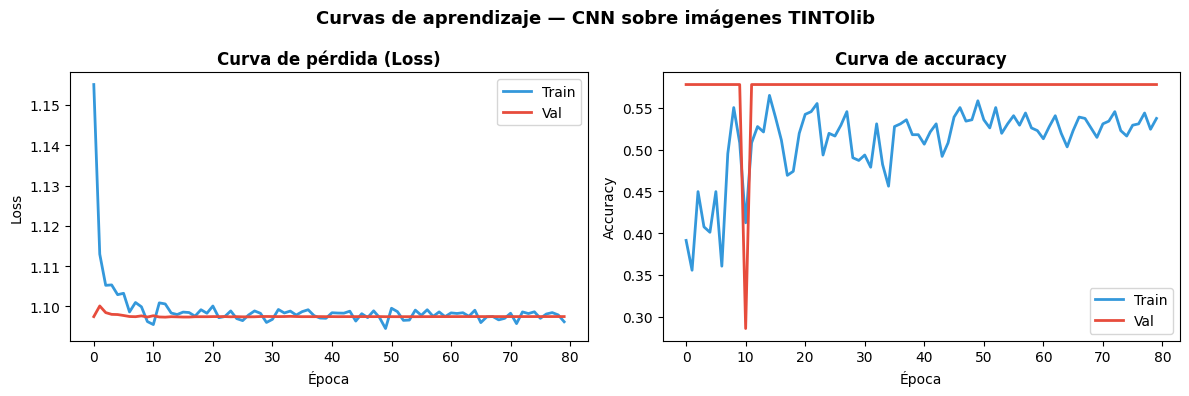

Accuracy final — Train: 0.537 | Val: 0.578


In [74]:
# Curvas de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(history['train_loss'], label='Train', color='#3498db', linewidth=2)
axes[0].plot(history['val_loss'],   label='Val',   color='#e74c3c', linewidth=2)
axes[0].set_title('Curva de pérdida (Loss)', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history['train_acc'], label='Train', color='#3498db', linewidth=2)
axes[1].plot(history['val_acc'],   label='Val',   color='#e74c3c', linewidth=2)
axes[1].set_title('Curva de accuracy', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

fig.suptitle('Curvas de aprendizaje — CNN sobre imágenes TINTOlib',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_curvas_aprendizaje.png', bbox_inches='tight')
plt.show()

print(f'Accuracy final — Train: {history["train_acc"][-1]:.3f} | '
      f'Val: {history["val_acc"][-1]:.3f}')

## 5. Extracción de embeddings

Con la CNN entrenada, pasamos TODAS las imágenes por la red y extraemos la salida
de la capa de embedding (64 dimensiones). Estos vectores son la representación
aprendida de cada momento de estrés y serán la entrada de los modelos ML.

In [75]:
model.eval()
todos_embeddings = []
todas_labels     = []

with torch.no_grad():
    for imgs, labels in full_loader:
        imgs = imgs.to(device)
        emb  = model.get_embedding(imgs)   # extrae embeddings
        todos_embeddings.append(emb.cpu().numpy())
        todas_labels.append(labels.numpy())

embeddings = np.vstack(todos_embeddings)   # (770, 64)
labels_arr = np.concatenate(todas_labels)  # (770,)

print(f'Shape embeddings: {embeddings.shape}')
print(f'  Filas (muestras):   {embeddings.shape[0]}')
print(f'  Columnas (dim emb): {embeddings.shape[1]}')

Shape embeddings: (770, 32)
  Filas (muestras):   770
  Columnas (dim emb): 32


## 6. Guardado para modelos ML

In [76]:
# Construir DataFrame de embeddings
cols_emb   = [f'emb_{i}' for i in range(EMBED_DIM)]
df_emb     = pd.DataFrame(embeddings, columns=cols_emb)

# Agregar etiquetas
df_emb['label_enc']    = labels_arr
df_emb['stress_label'] = le.inverse_transform(labels_arr)

df_emb.to_csv(OUTPUT_EMB, index=False)

print(f'✓ Embeddings guardados en: {OUTPUT_EMB}')
print(f'  Shape: {df_emb.shape}')
print(f'\n  Distribución de clases:')
print(df_emb['stress_label'].value_counts().sort_index())
print(f'\n  Primeras 3 filas (primeras 5 dims):')
print(df_emb[cols_emb[:5] + ['stress_label']].head(3))

✓ Embeddings guardados en: /content/drive/MyDrive/embeddings.csv
  Shape: (770, 34)

  Distribución de clases:
stress_label
0    443
1    220
2    107
Name: count, dtype: int64

  Primeras 3 filas (primeras 5 dims):
      emb_0     emb_1     emb_2     emb_3     emb_4  stress_label
0  0.008221 -0.017952  0.021321  0.029061  0.039418             0
1  0.009066 -0.018371  0.018552  0.030561  0.040362             0
2  0.009368 -0.018252  0.019668  0.030522  0.039449             0


In [78]:
print(df_emb['stress_label'].unique())
print(df_emb['stress_label'].dtype)

[0 1 2]
int64


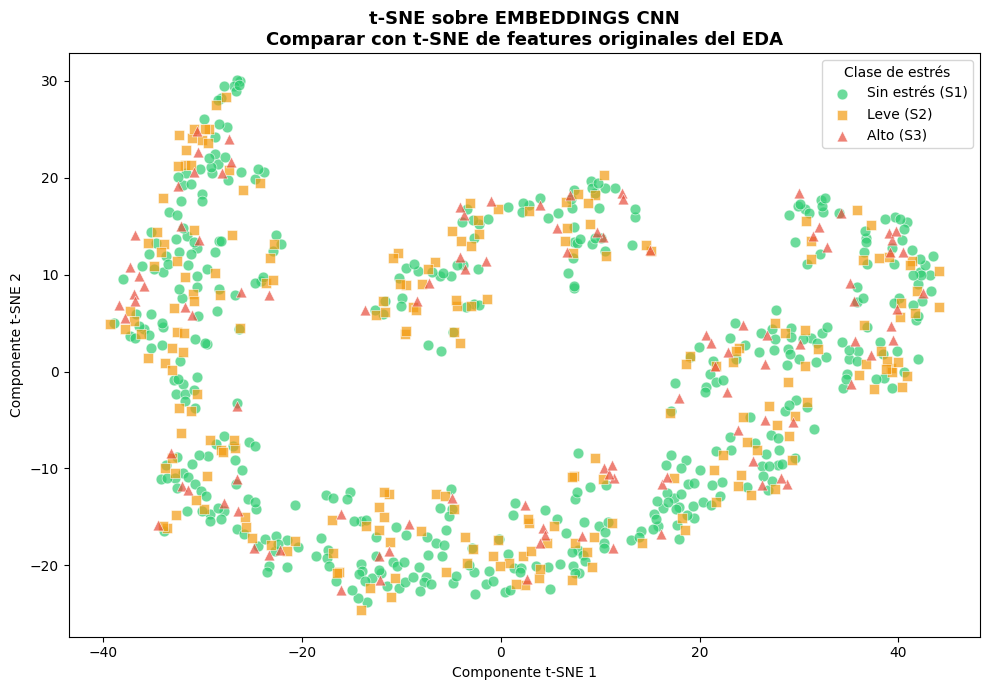

✓ t-SNE embeddings guardado: cnn_tsne_embeddings.png


In [79]:
# t-SNE sobre embeddings — comparar con t-SNE del EDA
from sklearn.manifold import TSNE

n_muestras = len(embeddings)
perplexity = min(30, int(np.sqrt(n_muestras)), n_muestras - 1)

tsne  = TSNE(n_components=2, random_state=RANDOM_SEED,
             perplexity=perplexity, n_iter=1000,
             learning_rate='auto', init='pca')
emb2d = tsne.fit_transform(embeddings)

# Visualizar
fig, ax = plt.subplots(figsize=(10, 7))
colores = {'S1':'#2ecc71','S2':'#f39c12','S3':'#e74c3c'}
marcadores = {'S1':'o','S2':'s','S3':'^'}
nombres = {'S1':'Sin estrés (S1)','S2':'Leve (S2)','S3':'Alto (S3)'}

for label_num, label_str in [(0,'S1'), (1,'S2'), (2,'S3')]:
    mask = df_emb['stress_label'] == label_num
    ax.scatter(emb2d[mask, 0], emb2d[mask, 1],
               c=colores[label_str], marker=marcadores[label_str],
               label=nombres[label_str], alpha=0.7,
               s=60, edgecolors='white', linewidths=0.5)

ax.set_title('t-SNE sobre EMBEDDINGS CNN\n'
             'Comparar con t-SNE de features originales del EDA',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Componente t-SNE 1')
ax.set_ylabel('Componente t-SNE 2')
ax.legend(title='Clase de estrés', fontsize=10)
plt.tight_layout()
plt.savefig('cnn_tsne_embeddings.png', bbox_inches='tight')
plt.show()

print('✓ t-SNE embeddings guardado: cnn_tsne_embeddings.png')

In [80]:
# Guardar modelo entrenado
torch.save(model.state_dict(), 'cnn_stress_model.pth')

print('=' * 50)
print('RESUMEN — CNN Embeddings')
print('=' * 50)
print(f"""
  Imágenes entrenadas:  {len(train_ds)}
  Imágenes validación:  {len(test_ds)}
  Accuracy validación:  {history['val_acc'][-1]:.3f}
  Dimensión embedding:  {EMBED_DIM}
  Embeddings totales:   {len(df_emb)}

  Archivos generados:
    embeddings.csv          ← entrada para modelos ML
    cnn_stress_model.pth    ← modelo guardado
    cnn_curvas_aprendizaje.png
    cnn_tsne_embeddings.png


RESUMEN — CNN Embeddings

  Imágenes entrenadas:  616
  Imágenes validación:  154
  Accuracy validación:  0.578
  Dimensión embedding:  32
  Embeddings totales:   770

  Archivos generados:
    embeddings.csv          ← entrada para modelos ML
    cnn_stress_model.pth    ← modelo guardado
    cnn_curvas_aprendizaje.png
    cnn_tsne_embeddings.png

  SIGUIENTE PASO → 06_modelos_ML.ipynb
  Entrenar Random Forest y SVM sobre embeddings,
  optimizar hiperparámetros y comparar con Wilcoxon

